# Tutorial for DTM module

In this tutorial, we will understand what is a Document-Term Matrix, its applications, and what the `dtm` module can achieve, as we go through the process of using real texts to create our own DTM, and explore what can be be done with it.

## Table of Contents

- [1. Prerequisites](#1-prerequisites)
- [2. About the Document-Term Matrix](#2-about-the-document-term-matrix)
  - [2.1 Note on sparse matrices](#21-note-on-sparse-matrices)
- [3. Preparing Your Documents](#3-preparing-your-documents)
  - [3.1 Using spaCy Doc objects](#31-using-spacy-doc-objects)
  - [3.2 Using lists of token strings](#32-using-lists-of-token-strings)
- [4. Understanding the Vectorizer](#4-understanding-the-vectorizer)
  - [4.1 What the Vectorizer Allows You to Do](#41-what-the-vectorizer-allows-you-to-do)
- [5. Building the DTM](#5-building-the-dtm)
  - [5.1 Loading the documents](#51-loading-the-documents)
  - [5.2 Preparing documents with Scrubber and spaCy docs](#52-preparing-documents-with-scrubber-and-spacy-docs)
  - [5.3. Creating a DTM](#53-creating-a-dtm)
  - [5.4 Accessing the DTM's class methods and properties](#54-accessing-the-dtms-class-methods-and-properties)
  - [5.5 Inspecting Terms and Counts](#55-inspecting-terms-and-counts)
  - [5.6 Accessing the dtm instance's attributes](#56-inspecting-terms-and-counts)
- [6. Converting to a DataFrame](#6-converting-to-a-dataframe)
  - [6.1 Customizing the DataFrame Output](#61-customizing-the-dataframe-output)
  - [6.2 Example with percentages with totals and two decimals](#62-example-with-percentages-with-totals-and-two-decimals)
- [7. Visualizing the DTM](#7-visualizing-the-dtm)
- [8. Applications and Experimentation](#8-applications-and-experimentation)
- [9. Running the Test Suite](#9-running-the-test-suite)

> **Note**
> 
> If you wish to go straight to building your own Document-Term Matrix, jump ahead to section [5. Building the DTM](#5-building-the-dtm).

<a id="1-prerequisites"></a>
## 1. Prerequisites

- Python ≥ 3.8  
- `lexos` installed (see main README)  
- NLP model for spaCy (if processing raw text, see main README)  

Before you begin, ensure you have Python 3.8 or higher installed on your system. The `lexos` package provides the DTM module and related utilities—install it using pip as described in the main README. If you plan to process raw text using spaCy (for tokenization, lemmatization, etc.), you will also need to download an appropriate spaCy language model (such as `en_core_web_sm`). This setup will allow you to follow the examples and workflows in this tutorial seamlessly.

<a id="2-about-the-document-term-matrix"></a>
## 2. About the Document-Term Matrix
A document-term matrix (DTM) is the standard interface for analysis and information of document data, consisting of a list of term (unique token) counts per document arranged as a matrix. In many real-world text collections, most documents only contain a small fraction of all possible terms, resulting in a sparse matrix where the majority of values are zero—this allows for highly efficient storage and processing. The DTM is fundamental in text analysis because it transforms a collection of documents into a structured, numerical format suitable for computational analysis, enabling a wide range of analyses such as identifying common terms, comparing document similarity, and serving as input for machine learning models. By quantifying textual data, the DTM makes it possible to apply statistical and algorithmic techniques to extract insights from text. 

In the Lexos App, sklearn's CountVectorizer is used to produce the DTM, while in the Lexos API, Textacy's Vectorizer is the default.

With the DTM module, you can:
- Build a DTM from Documents
- Access DTM Properties
- Convert DTM to a pandas DataFrame
- Customize Vectorization
- Inspect and Analize

Let's go through an overview of these capabilities using some real text as example.

<a id="21-note-on-sparse-matrices"></a>
### 2.1 Note on sparse matrices

A document-term matrix is typically very large and mostly filled with zeros, since each document only contains a small subset of all possible terms. This is called a "sparse matrix." In Lexos, the DTM is stored as a sparse matrix using efficient data structures from the `scipy.sparse` library. This allows you to work with large corpora without running into memory issues, and makes computations much faster. When you convert the DTM to a pandas DataFrame for analysis or visualization, the underlying data remains efficient and scalable.

You can learn more about the `scipy.sparse` library [here](https://docs.scipy.org/doc/scipy/reference/sparse.html)

> **Tip:**
> 
> If you need a dense (regular) matrix for certain operations or compatibility with other libraries, you can convert the sparse DataFrame to a dense one by calling:
> 
> ```python
> dense_df = dtm.to_df().sparse.to_dense()
> ```
>
> Be aware that this may use a lot of memory for large corpora.
> We will learn more on the `to_df()` method in section [6. Converting to a DataFrame](#6-converting-to-a-dataframe).


<a id="3-preparing-your-documents"></a>
## 3. Preparing Your Documents

You can supply documents in two formats to `DTM`:

<a id="31-using-spacy-doc-objects"></a>
### 3.1 Using spaCy `Doc` objects

spaCy `Doc` objects represent processed documents, containing tokens, linguistic annotations, and other useful metadata. The `DTM` module can directly accept lists of spaCy `Doc` objects as input, allowing you to leverage spaCy's robust tokenization and preprocessing capabilities. This is especially useful when you want to include linguistic features such as lemmatization, part-of-speech tagging, or custom token filtering before building your document-term matrix. Simply process your raw texts with spaCy and pass the resulting `Doc` objects to the `DTM` for analysis.

In [1]:
import spacy
from lexos.dtm import DTM

nlp = spacy.load("en_core_web_sm")
docs = [nlp("This is the first document."), nlp("Here is the second.")]
labels = ["Doc1", "Doc2"]

**What exactly is spaCy and a spaCy doc?**

spaCy is a popular open-source library for advanced Natural Language Processing (NLP) in Python. It provides fast and efficient tools for tokenizing, tagging, parsing, and analyzing text. 

A **spaCy Doc** is a core data structure representing a processed text document. It contains not just the original text, but also linguistic annotations such as tokens (words), part-of-speech tags, lemmas, named entities, and more. This makes it easy to perform complex text analysis and preprocessing tasks in a consistent and efficient way. In this tutorial, we use spaCy Docs to prepare our texts before building the Document-Term Matrix.

For more details, see the [spaCy Doc documentation](https://spacy.io/api/doc).

<a id="32-using-lists-of-token-strings"></a>
### 3.2 Using lists of token strings

Alternatively, you can provide your documents as lists of token strings, where each document is represented as a list of its tokens (words). Simply pass a list of these token lists to the `DTM` module, along with optional document labels. This method offers flexibility and allows you to integrate custom preprocessing workflows with the DTM functionality.

This approach is useful if you have already preprocessed your text (e.g., tokenized, cleaned, or filtered) and want to bypass spaCy's processing pipeline. For example, you might use this method if you have applied custom tokenization rules, removed stopwords, performed stemming or lemmatization with another library, or filtered out specific terms based on your research needs. It is especially helpful when working with non-standard text, domain-specific vocabularies, or when you want full control over the tokens included in your analysis.

In [2]:
docs = [["token1", "token2", "token10"], ["another", "set", "of", "tokens", "token10"]]
labels = ["T1", "T2"]

Summary Table:

| Input Format            | When to Use                                                                 | Advantages                                                                                   | Example Use Case                                  |
|-------------------------|-----------------------------------------------------------------------------|----------------------------------------------------------------------------------------------|---------------------------------------------------|
| **spaCy Doc objects**   | - When you want to leverage spaCy’s NLP features (lemmatization, POS, etc.)<br>- When you need consistent, language-aware tokenization<br>- When you plan to filter tokens using linguistic attributes | - Access to rich linguistic annotations<br>- Easy filtering (stopwords, punctuation, etc.)<br>- Robust for standard languages | Literary analysis with lemmatized tokens           |
| **Lists of token strings** | - When you have custom tokenization or preprocessing<br>- When working with non-standard text or languages not supported by spaCy<br>- When you want full control over included tokens | - Maximum flexibility<br>- Integrates with custom pipelines<br>- Useful for domain-specific or pre-tokenized data | Analyzing tweets with custom tokenization rules    |


> **Note**
>
> In this tutorial, we will mainly use spaCy docs as input, as demonstraded above, feel free to use each input format according to your needs. We demonstrate how the workflow would look using lists of token strings as well for each step of the process.

<a id="4-understanding-the-vectorizer"></a>
## 4. Understanding the Vectorizer

The `Vectorizer` is a core component that transforms your collection of documents into a numerical matrix format suitable for computational analysis.

A vectorizer is a tool that converts a collection of text documents into a structured numerical format—typically a matrix—where each row represents a document and each column represents a unique term (word or token) from the entire corpus.

In the Lexos DTM module, the `Vectorizer` is a Python class that acts as a factory for creating a `TextacyVectorizer` instance. When you create a `Vectorizer` object and call it, it returns a configured `TextacyVectorizer`, which is the object that actually performs the vectorization of our documents -converting tokenized documents, whether they are spaCy `Doc` objects or lists of token strings, into a document-term matrix (DTM). This design allows you to easily set up and reuse vectorizer configurations for different document-term matrices 

Here's how it works in context:

- The `Vectorizer` scans all documents to build a vocabulary of unique terms (tokens).
- It then counts the occurrences of each term in each document, resulting in a sparse matrix where rows represent documents and columns represent terms.
- This matrix is highly efficient for storage and computation, especially with large corpora, because it only stores nonzero values.
- The `Vectorizer` can be customized to use different tokenization, filtering, or weighting schemes, but in this tutorial, we use its default settings for simplicity.

By passing your preprocessed documents and labels to the `DTM` class (with the `Vectorizer`), you seamlessly generate a DTM that can be analyzed, converted to a DataFrame, or visualized—enabling powerful text analysis workflows with minimal code.

<a id="41-what-the-vectorizer-allows-you-to-do"></a>
### 4.1 What the Vectorizer Allows You to Do

- **Choose Term Frequency Type (`tf_type`)**
    - Options: `"linear"`, `"sqrt"`, `"log"`, `"binary"`
    - Controls how term frequencies are calculated (e.g., raw counts, log-scaled, binary presence/absence).

- **Choose Inverse Document Frequency Type (`idf_type`)**
    - Options: `None`, `"linear"`, `"sqrt"`, `"log"`
    - Controls how document frequency scaling is applied (for TF-IDF weighting).

- **Choose Document Length Normalization (`dl_type`)**
    - Options: `None`, `"linear"`, `"sqrt"`, `"log"`
    - Controls normalization based on document length.

- **Apply Vector Normalization (`norm`)**
    - Options: `None`, `"l1"`, `"l2"`
    - Normalizes the resulting vectors (rows) to unit length. L1 normalization scales the term frequencies in each document so that the sum of the absolute values equals 1. This means each document vector is divided by the sum of its term frequencies, turning the values into proportions that sum to 1. L2 normalization scales the term frequencies so that the sum of the squares of the values equals 1 (i.e., the Euclidean norm is 1). This is useful for algorithms that are sensitive to the length of the document vectors, such as cosine similarity.

- **Filter Terms by Frequency Across Documents**
    - `min_df`: Minimum number (or proportion) of documents a term must appear in to be included.
    - `max_df`: Maximum number (or proportion) of documents a term can appear in to be included.
    - Helps remove rare terms (noise) and very common terms (stopwords).

- **Limit Vocabulary Size (`max_n_terms`)**
    - Restricts the DTM to the top N most frequent terms.

- **Use a Custom Vocabulary (`vocabulary_terms`)**
    - Allows you to specify exactly which terms to include in the DTM.

- **Build a DTM from Tokenized Documents**
    - Accepts lists of token strings or spaCy Doc objects as input.

- **Integrate with the DTM Class**
    - The DTM class uses the vectorizer to build the document-term matrix, which can then be converted to a DataFrame, analyzed, or visualized.


Summary table:

| Parameter         | Purpose                                         |
|-------------------|-------------------------------------------------|
| tf_type           | How to count term frequency                     |
| idf_type          | How to scale by inverse document frequency      |
| dl_type           | How to normalize by document length             |
| norm              | How to normalize the resulting vectors          |
| min_df            | Minimum document frequency for terms            |
| max_df            | Maximum document frequency for terms            |
| max_n_terms       | Limit vocabulary to top N terms                 |
| vocabulary_terms  | Specify custom vocabulary                       |


The default settings for the `Vectorizer` are:

```python
tf_type: "linear"
idf_type: None
dl_type: None
norm: None
min_df: 1
max_df: 1.0
max_n_terms: None
vocabulary_terms: None
```

To better understand, this would mean the following:
- Term frequency type: "linear" (raw counts)
- Inverse document frequency: None (no IDF scaling)
- Document length normalization: None (no normalization)
- Vector normalization: None (no L1/L2 normalization)
- Minimum document frequency: 1 (term must appear in at least 1 document)
- Maximum document frequency: 1.0 (term can appear in up to 100% of documents)
- Maximum number of terms: None (no limit)
- Vocabulary terms: None (use all terms found)

> **Note**
>
> The Lexos culling function from the web app is now handled by the min_df parameter and extended by the max_df parameter in the vectorizer. The Lexos most frequent words function is handled by max_n_terms. See Section [5.3 Creating a DTM](#53-creating-a-dtm) for more details on how to use these parameters.
> 

<a id="5-building-the-dtm"></a>
## 5. Building the DTM

Let's use some real data from 13 classical texts, turn them into spaCy docs, and build ourselves a Document-Term Matrix, using the `DTM` Class from the Lexos library.


<a id="51-loading-the-documents"></a>
### 5.1 Loading the documents

We have 13 texts aquired in UTF txt format from the Project Gutenberg [website](https://www.gutenberg.org/), spanning from Shakespeare to Lewis Carroll saved in our `txt_files` directory. Let's load all of them at once., using lexos Loader class.

In [3]:
from lexos.io.loader import Loader
import os

try:
    loader = Loader()
    txt_dir = "txt_files"
    if not os.path.isdir(txt_dir):
        raise FileNotFoundError(f"Directory '{txt_dir}' does not exist.")
    loader.load([os.path.join(txt_dir)])
    if not loader.texts:
        raise ValueError("No texts were loaded. Please check your files in the directory.")
except Exception as e:
    print(f"Error loading texts: {e}")


**Note**
> If you have your own files to use, simply change the code above and use your corpus of interest!

<a id="52-preparing-documents-with-scrubber-and-spacy-docs"></a>
### 5.2 Preparing documents with Scrubber and spaCy docs

Let's prepare our documents by taking some undesired elements and turning them into spaCy docs.

We will first remove all punctuation, whitespaces, and digits, using Lexos' Scrubber module. Learn more on how it works by checking out the Scrubber module [README](../scrubber/scrubber_README.md)


In [ ]:
from lexos.dtm import DTM, Vectorizer
from lexos.scrubber.scrubber import Scrubber

# Use the loaded texts from loader and process them with spaCy
texts = loader.texts  # Use the loaded texts directly

# Scrub raw texts before spaCy processing
scrubber = Scrubber()
scrubber.add_pipe("punctuation")
scrubber.add_pipe("whitespace")
scrubber.add_pipe("new_lines")
scrubber.add_pipe("digits")  # Add/remove pipes as needed

# Apply scrubbing to all loaded texts
texts = list(scrubber.pipe(texts))

And now let's create the docs and add labels. It is worth mentioning that we are creating spaCy docs out of our text files. If we were working with pre-tokenized data, we could have alternatively used the list of token strings directly into our dtm, as seen in section [3.2](#32-using-lists-of-token-strings)

In [28]:

if not texts:
	print("No texts were loaded. Please check your file paths or data source.")
else:
	try:
		spacy_docs = [nlp(text) for text in texts]
	except Exception as e:
		print(f"spaCy processing failed: {e}")
		spacy_docs = []

	# Create new labels for each document if not already present
	labels = [
		"Alices Adventures in Wonderland by Lewis Carroll.txt",
		"Dracula by Bram Stoker.txt",
		"Frankenstein, Or, The Modern Prometheus.txt",
		"Metamorphosis by Franz Kafka.txt",
		"Pride and Prejudice by Jane Austen.txt",
		"Romeo and Juliet by William Shakespeare.txt",
		"The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt",
		"The Great Gatsby by F. Scott Fitzgerald.txt",
		"The Picture of Dorian Gray by Oscar Wilde.txt",
		"The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt",
		"Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche.txt"
	]

**Note**
> The labels are based on the files we have in hand and for easy recognition, but feel free to do it according to your own files, or to do it dynamically, with something like `labels = [f"Text_{i+1}" for i in range(len(texts))]`

<a id="53-creating-a-dtm"></a>
### 5.3. Creating a DTM

Now that we have our loaded texts as spaCy Docs, let's create a DTM instance, and call it with our documentes and labels

In [30]:
# Error handling for mismatched lengths or DTM construction errors
if not spacy_docs or not labels:
    print("Error: spacy_docs or labels is empty.")
elif len(spacy_docs) != len(labels):
    print(f"Error: Number of documents ({len(spacy_docs)}) does not match number of labels ({len(labels)}).")
else:
    try:
        dtm = DTM(vectorizer=Vectorizer())  # Creating a DTM instance
        dtm(docs=spacy_docs, labels=labels)  # Calling the DTM instance with our documents and labels
    except Exception as e:
        print(f"Error building DTM: {e}")

> **Note:**  
>  A reminder that. by default, `DTM(vectorizer=Vectorizer())` creates a document-term matrix where:
> - Each column represents a single word (unigram/1-gram) from your corpus.
> - Each cell contains the **raw count** of how many times that word appears in the document.
> - If you want to include bigrams or trigrams (sequences of 2 or 3 words), or use proportions or TF-IDF scores, you can customize the `Vectorizer` with additional parameters (see below).
>
> For example, to get proportions instead of raw counts, use `dtm.to_df(as_percent=True)`. To include bigrams, you would need to adjust the vectorizer settings (see the Textacy documentation for ngram support).

> **Note:**  
> In the alpha tutorial, the public method `build()` is mentioned for rebuilding (generating `self.doc_term_matrix`). This is now handled directly by calling the DTM instance itself (its `__call__` method) with docs and labels. The `__call__` method includes the logic to configure the vectorizer and build the matrix.

#### Customizing the Vectorizer

You can customize the vectorizer by passing keyword parameters when creating the `DTM` instance. For example, if you want to use TF-IDF weighting instead of raw counts, you can do so like this:

```python
dtm = DTM(tf_type="linear", idf_type="log")
```

You can also set the vectorizer's attributes directly, like so:

```python
dtm = DTM()
dtm.vectorizer.tf_type = "linear"
dtm.vectorizer.idf_type = "log"
```

Finally, you can pass keyword arguments to the vectorizer when calling the DTM class:

```python
dtm = DTM()
dtm(docs, labels, tf_type="linear", idf_type="log")
```

Which way you do it is a matter of personal preference, but one method may be preferable to another depending on the architecture of your application.

<a id="54-accessing-the-dtms-class-methods-and-properties"></a>
### 5.4 Accessing the DTM's class methods and properties

The DTM class has the following properties:
- `shape`: Returns the shape (number of documents, number of terms) of the DTM.
- `sorted_terms_list`: Returns a natsorted list of all terms in the DTM.
- `sorted_term_counts`: Returns a natsorted dictionary of terms and their total counts across all documents.

The DTM also has 2 methods:
- `__call__(docs, labels)`: Builds the DTM from a list of docs and labels.
- `to_df(by=None, ascending=True, as_percent=False, rounding=3, transpose=False, sum=False, mean=False, median=False)`:Returns the DTM as a pandas DataFrame, with many customization options. We will explore this a bit further later

Let's check out the shape property first:

In [9]:
print("DTM shape:", dtm.doc_term_matrix.shape)

DTM shape: (11, 33510)


**Note**

> By using Python's `@property` decorator in the DTM class definition, we can access the `shape`, `sorted_terms_list` and `sorted_term_counts` properties
like a regular attribute (e.g., `dtm.shape`), but its value is not stored directly—instead, it is dynamically computed each time you access it.
> When you write `dtm.shape`, Python automatically calls the method decorated with `@property`, which calculates and returns the current shape of the document-term matrix (typically as a tuple: `(number_of_documents, number_of_terms)`). This ensures that `shape` always reflects the latest state of the underlying matrix, even if the DTM is rebuilt or modified.
> Using `@property` allows you to access `shape` just like a simple attribute, while benefiting from up-to-date, on-demand computation under the hood.

<a id="55-inspecting-terms-and-counts"></a>
### 5.5 Inspecting Terms and Counts

To better understand the structure of your DTM, you can inspect the sorted list of unique terms (vocabulary) and their corresponding counts across all documents. The cell below demonstrates how to access the sorted list of terms using `dtm.sorted_terms_list` and retrieve a mapping of each term to its total count with `dtm.sorted_term_counts`. This allows you to quickly review which terms are present in your corpus and how frequently they appear, providing valuable insights before further analysis or visualization.

In [10]:
# Print samples from the sorted list of terms
unique_terms = dtm.sorted_terms_list
print("Sample terms:", unique_terms[:10])

# Print samples from the term counts mapping
counts = dtm.sorted_term_counts
sample_counts = dict(list(counts.items())[:10])
print("Sample term counts:", sample_counts)

Sample terms: ['\n', '\n\n', '\n\n ', '\n ', '\n \n', '\n \n ', '\n \n \n \n', '\n \n  ', '\n  ', ' ']
Sample term counts: {'\n': 74506, '\n\n': 112, '\n\n ': 1, '\n ': 1960, '\n \n': 107, '\n \n ': 111, '\n \n \n \n': 3, '\n \n  ': 1, '\n  ': 3, ' ': 452}


> **Note:**  
> In older versions of Lexos, you might have used `DTM.get_terms()` or `DTM.get_counts()`. These are now accessed directly as properties: `dtm.sorted_terms_list` and `dtm.sorted_term_counts`.

<a id="56-inspecting-terms-and-counts"></a>
### 5.6 Accessing the dtm instance's attributes

Additionally, the DTM instance has the following attributes for you to access:
- `docs`: The list of documents (as token lists or spaCy Doc objects).
- `labels`: The list of document labels.
- `vectorizer`: The vectorizer used to build the DTM (usually a TextacyVectorizer).
- `alg`: The sorting algorithm (from natsort).
- `doc_term_matrix`: The actual document-term matrix (scipy sparse matrix).
- `model_config`: The Pydantic model config (for validation).

In [11]:
# Check a bit of the DTM instance's attributes
print("Type of docs:", type(dtm.docs))
print("Sample doc (first 100 chars):", str(dtm.docs[0])[:100])
print("Labels:", dtm.labels)
print("Vectorizer type:", type(dtm.vectorizer))
print("Sorting algorithm:", dtm.alg)
print("doc_term_matrix shape:", dtm.doc_term_matrix.shape)
print("doc_term_matrix type:", type(dtm.doc_term_matrix))
print("Model config:", dtm.model_config)

Type of docs: <class 'list'>
Sample doc (first 100 chars): ['The', 'Project', 'Gutenberg', 'eBook', 'of', 'Alices', 'Adventures', 'in', 'Wonderland', '\n \n', 
Labels: ['Alices Adventures in Wonderland by Lewis Carroll.txt', 'Dracula by Bram Stoker.txt', 'Frankenstein, Or, The Modern Prometheus.txt', 'Metamorphosis by Franz Kafka.txt', 'Pride and Prejudice by Jane Austen.txt', 'Romeo and Juliet by William Shakespeare.txt', 'The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt', 'The Great Gatsby by F. Scott Fitzgerald.txt', 'The Picture of Dorian Gray by Oscar Wilde.txt', 'The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt', 'Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche.txt']
Vectorizer type: <class 'textacy.representations.vectorizers.Vectorizer'>
Sorting algorithm: 48
doc_term_matrix shape: (11, 33510)
doc_term_matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Model config: {'arbitrary_types_allowed': True, 'json_sche

<a id="6-converting-to-a-dataframe"></a>
## 6. Converting to a DataFrame

The cell below demonstrates how to convert the DTM object into a pandas DataFrame using the `to_df()` method. This allows for easier inspection, manipulation, and export of the document-term matrix, making it suitable for further analysis or visualization in pandas. We will also ensure that the rows indicate documents and columns indicate terms by transposing the DataFrame

In [12]:
import pandas as pd

try:
    df = dtm.to_df()
    if df.empty:
        print("The DataFrame is empty. The DTM may not be built or contains no data.")
    else:
        display(df)
        df = df.transpose()
        display(df)
except Exception as e:
    print(f"Error converting DTM to DataFrame: {e}")

,Alices Adventures in Wonderland by Lewis Carroll.txt,Dracula by Bram Stoker.txt,"Frankenstein, Or, The Modern Prometheus.txt",Metamorphosis by Franz Kafka.txt,Pride and Prejudice by Jane Austen.txt,Romeo and Juliet by William Shakespeare.txt,The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt,The Great Gatsby by F. Scott Fitzgerald.txt,The Picture of Dorian Gray by Oscar Wilde.txt,The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt,Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche.txt
groundless,0,1,0,1,0,0,0,0,0,0,0
mourn,0,1,3,0,0,0,0,0,0,0,1
mounting,0,0,0,0,1,0,0,0,0,0,0
mounteth,0,0,0,0,0,0,0,0,0,0,1
mounted,0,1,2,0,0,0,0,5,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...
a,672,2904,1395,341,2024,460,2579,1390,1618,662,1680
to,796,4490,2155,829,4310,534,2730,1197,2081,711,2527
and,844,5721,2997,673,3628,549,2865,1540,2136,971,3971
the,1692,7443,4073,1275,4515,781,5425,2376,3516,1668,5470


,groundless,mourn,mounting,mounteth,mounted,mountebanks,mountaintop,mountainstream,mountainsthey,mountainsdid,...,said,I,it,she,of,a,to,and,the,\n
Alices Adventures in Wonderland by Lewis Carroll.txt,0,0,0,0,0,0,0,0,0,0,...,458,503,505,507,608,672,796,844,1692,2683
Dracula by Bram Stoker.txt,1,1,0,0,1,0,1,0,0,0,...,567,4741,1781,640,3703,2904,4490,5721,7443,12863
"Frankenstein, Or, The Modern Prometheus.txt",0,3,0,0,2,0,1,1,1,0,...,102,2842,460,182,2747,1395,2155,2997,4073,6633
Metamorphosis by Franz Kafka.txt,1,0,0,0,0,0,0,0,0,0,...,51,81,324,172,544,341,829,673,1275,2032
Pride and Prejudice by Jane Austen.txt,0,0,1,0,0,0,0,0,0,0,...,405,2105,1332,1418,3933,2024,4310,3628,4515,11390
Romeo and Juliet by William Shakespeare.txt,0,0,0,0,0,0,0,0,0,0,...,13,580,204,100,478,460,534,549,781,4207
The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt,0,0,0,0,0,0,0,0,0,0,...,486,3011,1287,330,2736,2579,2730,2865,5425,9483
The Great Gatsby by F. Scott Fitzgerald.txt,0,0,0,0,5,0,0,0,0,0,...,233,1339,423,278,1209,1390,1197,1540,2376,4925
The Picture of Dorian Gray by Oscar Wilde.txt,0,0,0,0,1,0,0,0,0,0,...,262,1679,968,272,2254,1618,2081,2136,3516,7147
The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt,0,0,0,0,3,0,0,0,0,0,...,130,638,294,18,1044,662,711,971,1668,2420


<a id="61-customizing-the-dataframe-output"></a>
### 6.1 Customizing the DataFrame Output

You can tailor the output of your document-term matrix DataFrame using several options in the `to_df()` method:

- **Sort by a specific column:**  
    Use the `by` parameter to sort the DataFrame by a particular document label (e.g., `by="T2"`). By default, the DataFrame is sorted by the first label.

- **Control sort order:**  
    Set `ascending=False` to sort in descending order (largest to smallest values). The default is `ascending=True` for ascending order.

- **Display percentages instead of raw counts:**  
    Set `as_percent=True` to show term frequencies as percentages of the total terms in each document, rather than raw counts. This is useful for comparing documents of different lengths.

- **Adjust decimal precision:**  
    Use the `rounding` parameter to specify the number of decimal places for percentages (e.g., `rounding=2` for two decimals). The default is 1 decimal place.

- **Add row statistics:**  
    Include summary statistics for each term across all documents by setting `sum=True` (total count), `mean=True` (average count), or `median=True` (median count). These columns help you quickly identify the most common or distinctive terms.

- **Transpose the matrix:**  
    Set `transpose=True` to swap rows and columns, so that documents become columns and terms become rows. This can be helpful for certain types of analysis or visualization.

> **Note:**  
> The `as_percent`, `sum`, `mean`, and `median` parameters now replace the need for separate `get_freq_table()` or `get_stats_table()` methods found in earlier versions. This demonstrates the API's simplification—everything is handled directly through `to_df()`, allowing you to customize the DataFrame to best suit your analysis and reporting needs.


<a id="62-example-with-percentages-with-totals-and-two-decimals"></a>
#### 6.2 Example with percentages with totals and two decimals

This example demonstrates how to convert the document-term matrix to a DataFrame that displays term frequencies as percentages, rounded to two decimal places, and includes a total count column for each term. This format makes it easy to compare term usage across documents of different lengths and quickly identify the most frequent terms in the corpus.

In [13]:
df_pct = dtm.to_df(
    as_percent=True,
    rounding=2,
    sum=True
)
df_pct = df_pct.transpose()
df_pct

,groundless,mourn,mounting,mounteth,mounted,mountebanks,mountaintop,mountainstream,mountainsthey,mountainsdid,...,said,I,it,she,of,a,to,and,the,\n
Alices Adventures in Wonderland by Lewis Carroll.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.05,0.05,0.06,0.07,0.07,0.09,0.09,0.18,0.29
Dracula by Bram Stoker.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.06,0.52,0.19,0.07,0.40,0.32,0.49,0.62,0.81,1.40
"Frankenstein, Or, The Modern Prometheus.txt",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,0.31,0.05,0.02,0.30,0.15,0.23,0.33,0.44,0.72
Metamorphosis by Franz Kafka.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,0.01,0.04,0.02,0.06,0.04,0.09,0.07,0.14,0.22
Pride and Prejudice by Jane Austen.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.04,0.23,0.14,0.15,0.43,0.22,0.47,0.39,0.49,1.24
Romeo and Juliet by William Shakespeare.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.06,0.02,0.01,0.05,0.05,0.06,0.06,0.09,0.46
The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.33,0.14,0.04,0.30,0.28,0.30,0.31,0.59,1.03
The Great Gatsby by F. Scott Fitzgerald.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.03,0.15,0.05,0.03,0.13,0.15,0.13,0.17,0.26,0.54
The Picture of Dorian Gray by Oscar Wilde.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.03,0.18,0.11,0.03,0.25,0.18,0.23,0.23,0.38,0.78
The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,0.07,0.03,0.00,0.11,0.07,0.08,0.11,0.18,0.26


Or if you want a table sorted using pandas to get the most frequent terms

In [14]:
# Create a DataFrame of terms and their total counts, sorted by count descending
term_counts_df = pd.DataFrame(list(counts.items()), columns=["term", "count"])
term_counts_df = term_counts_df.sort_values(by="count", ascending=False).reset_index(drop=True)
term_counts_df

,term,count
0,\n,74506
1,the,38234
2,and,25895
3,to,22360
4,of,22088
...,...,...
33505,diseasefor,1
33506,otherspoor,1
33507,othersthough,1
33508,otherswhy,1


> **Note:**
> In the alpha tutorial, the `DTM.get_table()` method is mentioned, for getting a raw term count. This functionality has been entirely consolidated into the `DTM.to_df()` method, where raw counts are the default output if `as_percent` is `False`.
> Additionally, the alpha tutorial states that it is possible to simply call `DTM.table` that would return a table based on the state after the last time `DTM.build()` was called. Now, the panda df output is always generated on demand by calling `DTM.to_df()`

<a id="7-visualizing-the-dtm"></a>
## 7. Visualizing the DTM
The DataFrame output from `to_df()` makes it easy to visualize your document-term matrix using standard pandas plotting methods. Let's generate two simple graphs:

The bar chart below displays the top 20 most frequent terms across our entire corpus of classical texts. Each bar represents a term, and its height corresponds to the total number of times that term appears in all documents combined.

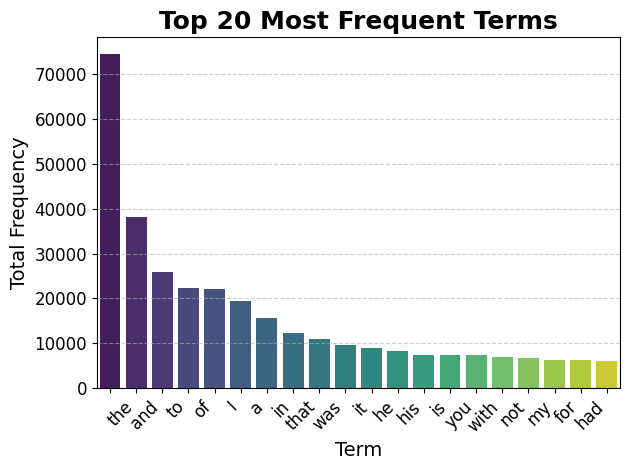

In [15]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

top_n = 20
term_totals = df.sum(axis=0).sort_values(ascending=False)[:top_n]

if term_totals.empty:
    print("No term frequencies to plot. The DataFrame may be empty or contain no data.")
else:
    sns.barplot(
        x=term_totals.index,
        y=term_totals.values,
        hue=term_totals.index,
        palette="viridis",
        legend=False
    )
    plt.title(f"Top {top_n} Most Frequent Terms", fontsize=18, weight="bold")
    plt.ylabel("Total Frequency", fontsize=14)
    plt.xlabel("Term", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

We can even use Lexos' own `cloud` module to generate a word cloud of the most frequent terms in our corpus. In this visualization, each word's size is proportional to its overall frequency in the corpus—the larger the word appears, the more often it occurs.

In [16]:
try:
    from lexos.visualization.cloud import wordcloud
    # Make a word cloud of the most frequent terms in your corpus
    wordcloud(dtm)
except Exception as e:
    print(f"Could not generate word cloud: {e}")

Could not generate word cloud: anchor not supported for multiline text


In addition to these basic visualizations, the Lexos API provides built-in tools for more advanced visualizations. For more details and examples, refer to the [Visualization page](#) or the relevant Lexos API documentation. These tools help you explore and present your text data more effectively.

<a id="8-applications-and-experimentation"></a>
## 8. Applications and Experimentation
By building and analyzing a Document-Term Matrix (DTM), you unlock a wide range of real-world applications in text analysis and natural language processing. Here are some practical ways to apply these techniques:

- **Text Classification:** Use the DTM as input features for machine learning models to classify documents by topic, sentiment, or author.
- **Topic Modeling:** Identify underlying themes in large corpora by applying algorithms like Latent Dirichlet Allocation (LDA) to the DTM.
- **Authorship Attribution:** Compare term usage patterns across documents to attribute anonymous texts to likely authors.
- **Plagiarism Detection:** Measure document similarity using DTM-based metrics to detect copied or closely paraphrased content.
- **Trend Analysis:** Track the frequency of specific terms or topics over time to analyze trends in news, literature, or social media.
- **Keyword Extraction:** Identify the most distinctive or frequent terms in a set of documents for summarization or search optimization.
- **Corpus Exploration:** Visualize and explore large text collections to uncover patterns, outliers, or clusters of related documents.

By converting raw text into structured, quantitative data with the DTM, you can apply statistical, machine learning, and visualization techniques to gain actionable insights from textual information in fields such as digital humanities, marketing, social sciences, and beyond.

In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.cluster import KMeans

# Example applications using the loaded texts and DTM

# 1. Text Classification (e.g., classify by author using term frequencies)

# For demonstration, let's assign a dummy author label to each document
authors = [
    "Carroll", "Stoker", "Shelley", "Kafka", "Austen", "Shakespeare",
    "Doyle", "Fitzgerald", "Wilde", "Stevenson", "Nietzsche"
]
# If there are more documents, extend or repeat author labels as needed
y = authors[:len(labels)]

X = dtm.doc_term_matrix.toarray()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = MultinomialNB().fit(X_train, y_train)
print("Text Classification accuracy:", clf.score(X_test, y_test))

Text Classification accuracy: 0.0


In [18]:
# 2. Topic Modeling (LDA)

lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)
for idx, topic in enumerate(lda.components_):
    top_terms = [dtm.sorted_terms_list[i] for i in topic.argsort()[-5:][::-1]]
    print(f"Topic {idx+1} top terms:", top_terms)


Topic 1 top terms: ['\n', 'trusting', 'described', 'protruding', 'Turks']
Topic 2 top terms: ['\n', 'trusting', 'described', 'Turks', 'protruding']


In [19]:
# 3. Authorship Attribution (find most likely author for a new text)
test_text = nlp("It was a bright cold day in April, and the clocks were striking thirteen.")
test_doc = nlp.make_doc(" ".join([
    token.text for token in test_text
    if not (token.is_space or token.is_punct or token.is_stop)
]))
test_vec = dtm.vectorizer.transform([test_doc])
predicted_author = clf.predict(test_vec.toarray())[0]
print("Predicted author for test text:", predicted_author)

Predicted author for test text: Austen


In [20]:
# 4. Plagiarism Detection (cosine similarity between documents)

similarity_matrix = cosine_similarity(X)
np.fill_diagonal(similarity_matrix, 0)
most_similar = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
print(f"Most similar documents: {labels[most_similar[0]]} and {labels[most_similar[1]]} (similarity={similarity_matrix[most_similar]:.2f})")

Most similar documents: Dracula by Bram Stoker.txt and The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt (similarity=0.99)


In [21]:
# 5. Trend Analysis (track frequency of a term across documents)
term = "said"
if term in dtm.sorted_terms_list:
    idx = dtm.sorted_terms_list.index(term)
    term_freqs = X[:, idx]
    for label, freq in zip(labels, term_freqs):
        print(f"Frequency of '{term}' in '{label}': {freq}")
else:
    print(f"Term '{term}' not found in vocabulary.")

Frequency of 'said' in 'Alices Adventures in Wonderland by Lewis Carroll.txt': 0
Frequency of 'said' in 'Dracula by Bram Stoker.txt': 0
Frequency of 'said' in 'Frankenstein, Or, The Modern Prometheus.txt': 0
Frequency of 'said' in 'Metamorphosis by Franz Kafka.txt': 0
Frequency of 'said' in 'Pride and Prejudice by Jane Austen.txt': 1
Frequency of 'said' in 'Romeo and Juliet by William Shakespeare.txt': 0
Frequency of 'said' in 'The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt': 0
Frequency of 'said' in 'The Great Gatsby by F. Scott Fitzgerald.txt': 0
Frequency of 'said' in 'The Picture of Dorian Gray by Oscar Wilde.txt': 0
Frequency of 'said' in 'The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt': 0
Frequency of 'said' in 'Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche.txt': 0


In [22]:
# 6. Keyword Extraction (top terms in a document)
doc_idx = 0
top_terms_idx = X[doc_idx].argsort()[-5:][::-1]
top_terms = [dtm.sorted_terms_list[i] for i in top_terms_idx]
print(f"Top terms in '{labels[doc_idx]}':", top_terms)

Top terms in 'Alices Adventures in Wonderland by Lewis Carroll.txt': ['\n', 'trusting', 'described', 'Turks', 'Cold']


In [23]:
# 7. Corpus Exploration (cluster documents by similarity)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
for i, label in enumerate(labels):
    print(f"Document '{label}' assigned to cluster {kmeans.labels_[i]}")

Document 'Alices Adventures in Wonderland by Lewis Carroll.txt' assigned to cluster 1
Document 'Dracula by Bram Stoker.txt' assigned to cluster 2
Document 'Frankenstein, Or, The Modern Prometheus.txt' assigned to cluster 1
Document 'Metamorphosis by Franz Kafka.txt' assigned to cluster 1
Document 'Pride and Prejudice by Jane Austen.txt' assigned to cluster 0
Document 'Romeo and Juliet by William Shakespeare.txt' assigned to cluster 1
Document 'The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt' assigned to cluster 0
Document 'The Great Gatsby by F. Scott Fitzgerald.txt' assigned to cluster 1
Document 'The Picture of Dorian Gray by Oscar Wilde.txt' assigned to cluster 1
Document 'The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt' assigned to cluster 1
Document 'Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche.txt' assigned to cluster 0


<a id="9-running-the-test-suite"></a>
## 9. Running the Test Suite

Also included in this repository is a comprehensive test suite of the dtm module. Before running the tests, make sure you are in the `uv_lexos` directory:
```bash
cd uv_lexos
```
Then run the following command in your terminal, assuming you are using `uv` as well:
```bash
uv run pytest tests/dtm
```

The test suite was found to have 100% coverage. This can be verified with the following commands:
```bash
uv run pytest --cov=src/lexos/dtm --cov-report=html tests/dtm
```
